# Image Compression using Modulo-Compressive Sensing

## Importing Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimization.milp import solve_modulo_cs_milp
from optimization.moram import MultiScaleMoRAM

## Data Exploration

In [2]:
# load csv data to a numpy array
# train_data = np.loadtxt('data/mnist_train.csv', delimiter=',')
test_data = np.loadtxt('data/mnist_test.csv', delimiter=',')

In [3]:
test_data.shape

(10000, 785)

## Generating CS Matrix

In [4]:
def generate_CS_matrix(M:int, N:int=785):
    # Generate N vectors of dimension M from a standard Gaussian distribution
    A = np.array([np.random.randn(M) for _ in range(N)]).T
    # normalizing each column of A to a unit norm
    A = A / np.expand_dims(np.linalg.norm(A, ord=2, axis=1), axis=1)

    return A

## Generating Measurements

In [5]:
def generate_measurements(image_data: np.ndarray, num_measurements: int) -> tuple[np.ndarray, np.ndarray]:
    """
        Generate modulo measurements y = [[Ax]], where [[]] denotes the fractional parts of the elements of the vector Ax
        
        Parameters:
            - image_data: np.ndarray flattened vector of the image pixel values
            - num_measurements: int number of samples to be acquired of the 'densified' sparse image

        Returns:
            - np.ndarray: acquired samples y
            - np.ndarray: 2D compressed-sensing matrix    
    """
    
    num_pixels = len(image_data)
    # generating a normalized Gaussian-distributed Compressed Sensing Matrix
    A = generate_CS_matrix(M=num_measurements, N=num_pixels) # M < N
    # acquiring dense modulo samples from the sparse image vector
    y_dense = A @ image_data
    y = y_dense - np.floor(y_dense)

    return y, A

## Sparse Image Recovery

In [6]:
image_idx = np.floor(np.random.rand()*10000).astype('int')
image = test_data[image_idx,1:]
image_idx

np.int64(8060)

In [7]:
y, A = generate_measurements(image_data=image, num_measurements=200)
z = A @ image

In [8]:
np.min(z), np.max(z)

(np.float64(-287.80831298388114), np.float64(239.8642287952236))

In [9]:
A.shape

(200, 784)

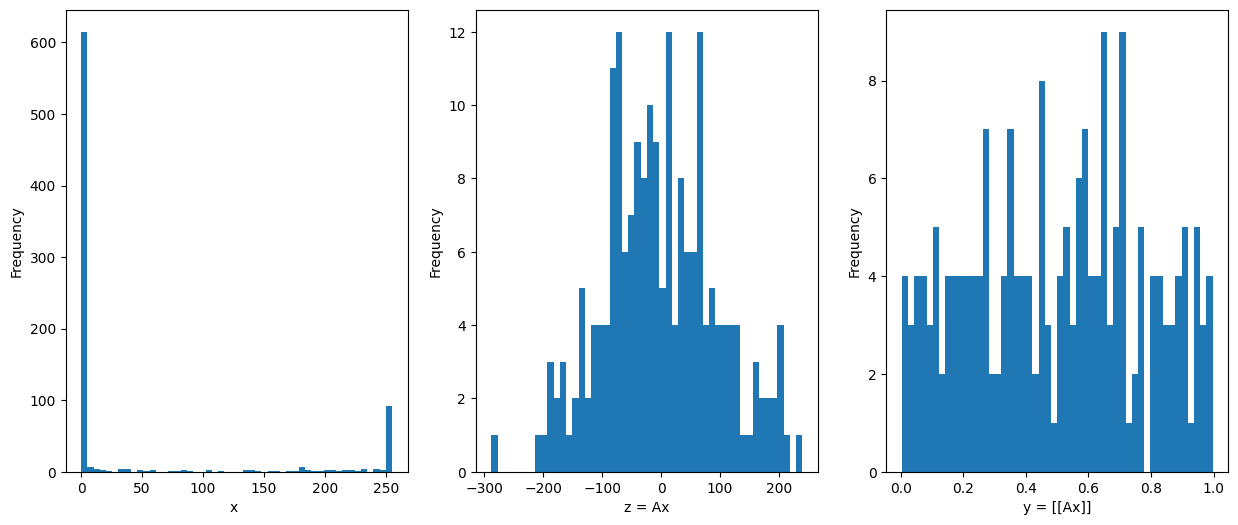

In [10]:
# plotting the distribution of measurements
plt.figure(figsize=(15, 6))

plt.subplot(1,3,1)
plt.hist(image, bins=50)
plt.xlabel('x ')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
plt.hist(z, bins=50)
plt.xlabel('z = Ax')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
plt.hist(y, bins=50)
plt.xlabel('y = [[Ax]]')
plt.ylabel('Frequency')

plt.tight_layout
plt.show()

### Multi-Scale MoRAM

In [11]:
ms_moram = MultiScaleMoRAM(
    cs_matrix=A, max_level=256, 
    max_moram_iters=200,
    print_debug_errors=True
)

x_est = ms_moram.recover(y)

AFTER 1.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 2.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 4.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 8.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 16.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 32.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 64.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724
AFTER 128.0-FOLD-WIDTH SCALING, (relative) l2-norm error                        = 0.9999998756177724


KeyboardInterrupt: 

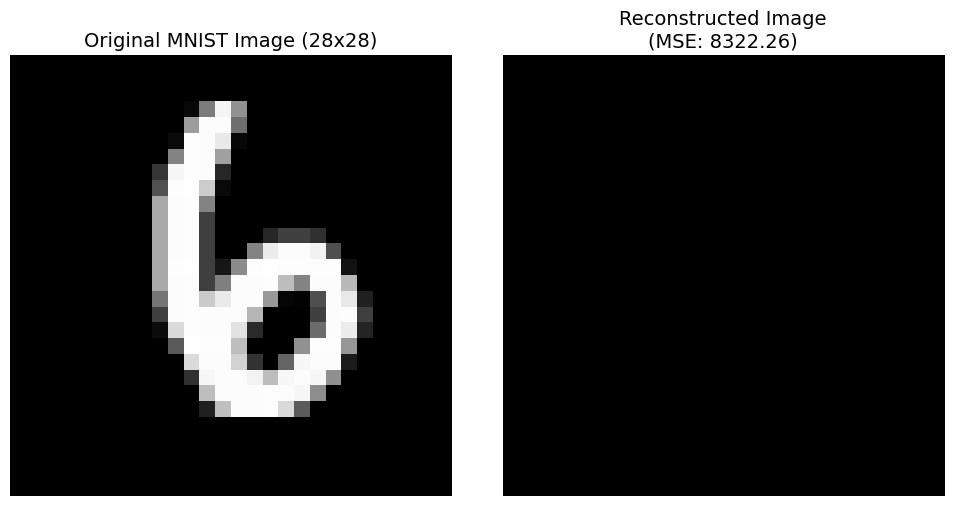

In [ ]:
# reshaping the arrrays
reconstructed_scaled = np.clip(x_est, 0.0, 255.0)
img_reconstructed = reconstructed_scaled.reshape(28, 28)

# 4. Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image Plot (Using the 14x14 downsampled image 'img_small')
axes[0].imshow(image.reshape(28,28), cmap='gray')
axes[0].set_title("Original MNIST Image (28x28)", fontsize=14)
axes[0].axis('off')

# Reconstructed Image Plot
axes[1].imshow(img_reconstructed, cmap='gray')
axes[1].set_title(f"Reconstructed Image\n(MSE: {(np.linalg.norm(image - x_est)**2)/784:.2f})", fontsize=14)
axes[1].axis('off')

plt.tight_layout()

# plt.savefig("reconstruction14x14_1.png", dpi=300)
plt.show()

### MILP

In [ ]:
# x_reconst, integer_part, res = solve_modulo_cs_milp(A, y, v_bound=750)